In [4]:
import torchvision
from torchvision import transforms

# MNIST dataset
root_path = '/home/storopoli/Downloads' # mude isso no Colab se necessário

# trans_aumentado = transforms.Compose([
#     transforms.RandomAffine(
#         degrees=0,  # Sem rotação
#         translate=(0.1, 0.1),  # Translacao de ate 10% em x e y
#         scale=(0.9, 1.1)  # Zoom entre 90% e 110%
#     ),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),  # Perspectiva com 50% de probabilidade
#     transforms.ToTensor(),
#     transforms.Normalize((0.1307,), (0.3081,))
# ])

# Pequena transformação para tensores e normalizando o tamanho
baseline_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

basic_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])

advanced_transform = transforms.Compose([
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.RandomErasing(p=0.5)
    ])

In [5]:
from torch.utils.data import DataLoader, random_split

In [6]:
# Baseline
baseline_train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=baseline_transform, download=True)
baseline_test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=baseline_transform)

# Básico
basic_train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=basic_transform, download=True)
basic_test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=baseline_transform)

# Avançado
advanced_train_dataset = torchvision.datasets.MNIST(root=root_path, train=True, transform=advanced_transform, download=True)
advanced_test_dataset = torchvision.datasets.MNIST(root=root_path, train=False, transform=baseline_transform)

# DataLoaders
batch_size = 32

pipelines = {
    'Baseline': {
        'train_loader': DataLoader(dataset=baseline_train_dataset, batch_size=batch_size, shuffle=True),
        'test_loader': DataLoader(dataset=baseline_test_dataset, batch_size=batch_size, shuffle=False)
    },
    'Básico': {
        'train_loader': DataLoader(dataset=basic_train_dataset, batch_size=batch_size, shuffle=True),
        'test_loader': DataLoader(dataset=basic_test_dataset, batch_size=batch_size, shuffle=False)
    },
    'Avançado': {
        'train_loader': DataLoader(dataset=advanced_train_dataset, batch_size=batch_size, shuffle=True),
        'test_loader': DataLoader(dataset=advanced_test_dataset, batch_size=batch_size, shuffle=False)
    }
}


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


In [7]:
baseline_train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /home/storopoli/Downloads
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [8]:
baseline_test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: /home/storopoli/Downloads
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [9]:
import torch.nn as nn

In [10]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc1 = nn.Sequential(
            nn.Linear(7 * 7 * 64, 1000),
            nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instancia o Model()
model = ConvNet()

print(model)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(model)

3199106

In [26]:
from torch.optim import Adam

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)

In [13]:
# Isto tem que retornar True
import torch
torch.cuda.is_available()

True

In [14]:
# Sua GPU
torch.cuda.get_device_name()

'Tesla T4'

In [23]:
from torchvision.transforms import v2
mixup = v2.MixUp(num_classes=10, alpha=1.0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [32]:
resultados = {}
historico = {}

for pipeline_name, data_loaders in pipelines.items():
    print(f"\n{'='*50}")
    print(f"Iniciando treinamento para a pipeline: {pipeline_name}")
    print(f"{'='*50}")

    train_loader = data_loaders['train_loader']
    test_loader = data_loaders['test_loader']

    model = ConvNet().to(device)
    optimizer = Adam(model.parameters(), lr=learning_rate)

    historico[pipeline_name] = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    total_step = len(train_loader)

    for epoch in range(epochs):
        model.train()
        train_loss_epoch = 0.0
        correct_train = 0
        total_train = 0

        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            images_mixed, labels_mixed = mixup(images, labels)

            outputs = model(images_mixed)
            loss = loss_fn(outputs, labels_mixed)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            _, true_dominant = torch.max(labels_mixed, 1)
            correct_train += (predicted == true_dominant).sum().item()
            total_train += labels.size(0)

            if (i + 1) % 500 == 0:
                # Calcula a acurácia específica deste batch para mostrar no print
                acc_step = (predicted == true_dominant).sum().item() / labels.size(0)
                print(f"  -> Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo: {loss.item():.3f}, Acurácia Aprox.: {acc_step*100:.2f}%")

        avg_train_loss = train_loss_epoch / len(train_loader)
        avg_train_acc = correct_train / total_train

        historico[pipeline_name]['train_loss'].append(avg_train_loss)
        historico[pipeline_name]['train_acc'].append(avg_train_acc)

        model.eval()
        val_loss_epoch = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = loss_fn(outputs, labels)

                val_loss_epoch += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss_epoch / len(test_loader)
        avg_val_acc = correct_val / total_val

        historico[pipeline_name]['val_loss'].append(avg_val_loss)
        historico[pipeline_name]['val_acc'].append(avg_val_acc)

        print(f"Época [{epoch+1}/{epochs}] | Treino - Loss: {avg_train_loss:.4f}, Acc: {avg_train_acc*100:.2f}% | Val - Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc*100:.2f}%")

    resultados[pipeline_name] = historico[pipeline_name]['val_acc'][-1] * 100


Iniciando treinamento para a pipeline: Baseline
  -> Época [1/6], Step [500/1875], Custo: 0.966, Acurácia Aprox.: 93.75%
  -> Época [1/6], Step [1000/1875], Custo: 1.032, Acurácia Aprox.: 81.25%
  -> Época [1/6], Step [1500/1875], Custo: 0.880, Acurácia Aprox.: 68.75%
Época [1/6] | Treino - Loss: 0.8217, Acc: 86.83% | Val - Loss: 0.0699, Acc: 98.72%
  -> Época [2/6], Step [500/1875], Custo: 1.031, Acurácia Aprox.: 71.88%
  -> Época [2/6], Step [1000/1875], Custo: 0.770, Acurácia Aprox.: 90.62%
  -> Época [2/6], Step [1500/1875], Custo: 0.745, Acurácia Aprox.: 62.50%
Época [2/6] | Treino - Loss: 0.6657, Acc: 88.52% | Val - Loss: 0.0649, Acc: 99.09%
  -> Época [3/6], Step [500/1875], Custo: 0.901, Acurácia Aprox.: 62.50%
  -> Época [3/6], Step [1000/1875], Custo: 0.821, Acurácia Aprox.: 56.25%
  -> Época [3/6], Step [1500/1875], Custo: 0.770, Acurácia Aprox.: 65.62%
Época [3/6] | Treino - Loss: 0.6243, Acc: 89.44% | Val - Loss: 0.0516, Acc: 99.13%
  -> Época [4/6], Step [500/1875], Cust

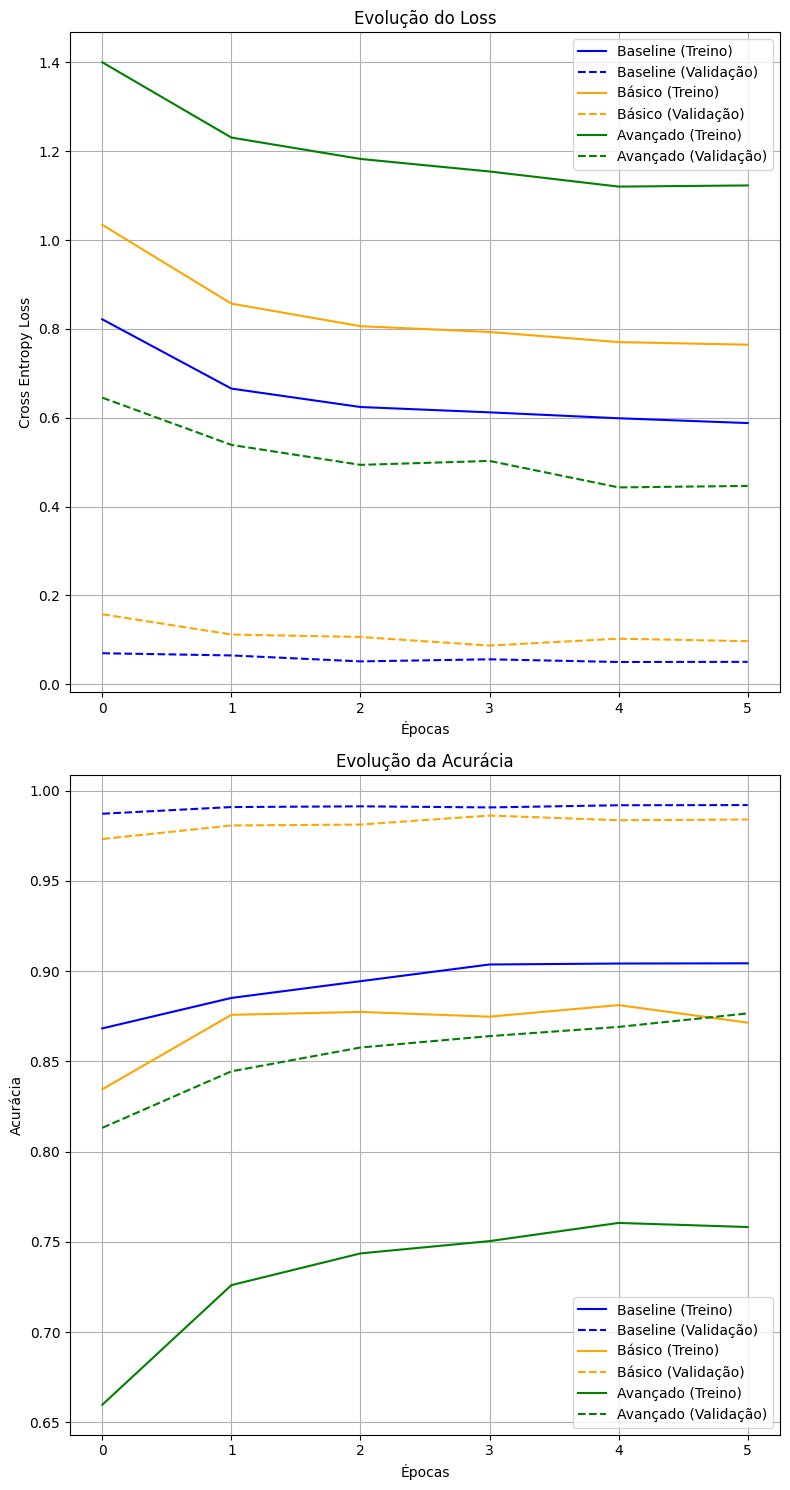

In [38]:
import matplotlib.pyplot as plt

cores = {'Baseline': 'blue', 'Básico': 'orange', 'Avançado': 'green'}

fig, (ax1, ay1) = plt.subplots(2, 1, figsize=(8, 15))

for pipeline_name, metricas in historico.items():
    cor = cores[pipeline_name]
    ax1.plot(metricas['train_loss'], label=f'{pipeline_name} (Treino)', color=cor, linestyle='-')
    ax1.plot(metricas['val_loss'], label=f'{pipeline_name} (Validação)', color=cor, linestyle='--')

ax1.set_title("Evolução do Loss")
ax1.set_xlabel("Épocas")
ax1.set_ylabel("Cross Entropy Loss")
ax1.legend()
ax1.grid(True)

for pipeline_name, metricas in historico.items():
    cor = cores[pipeline_name]
    ay1.plot(metricas['train_acc'], label=f'{pipeline_name} (Treino)', color=cor, linestyle='-')
    ay1.plot(metricas['val_acc'], label=f'{pipeline_name} (Validação)', color=cor, linestyle='--')

ay1.set_title("Evolução da Acurácia")
ay1.set_xlabel("Épocas")
ay1.set_ylabel("Acurácia")
ay1.legend()
ay1.grid(True)

plt.tight_layout()
plt.show()